In [1]:
library(Seurat)
library(SeuratData)
library(ggplot2)
library(patchwork)
library(dplyr)
library(stringr)
library(BuenColors)
library(Signac)
library(EnsDb.Mmusculus.v79)
library(ComplexHeatmap)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Installed datasets ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── SeuratData v0.2.2 ──

✔ stxBrain 0.1.1                                                                                                       


───────────────────────────────────────────────────────────────────────────────────────────────────────────────────── Key ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

✔ Dataset loaded successfully
❯ Dataset built with a newer version of Seurat than installed
❓ Unknown version of Seurat installed



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:


In [8]:
gene_annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Mmusculus.v79)
seqlevelsStyle(gene_annotations) <- 'UCSC'
gene_annotations <- keepStandardChromosomes(gene_annotations, pruning.mode="coarse")
genome(gene_annotations) <- "mm10"

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

In [3]:
setwd('/gpfs/commons/groups/vickovic_lab/rhe/projects/005/space_tag_reproducibility/fig2')

In [5]:
e_distance <- function(group_1, group_2, obj){
  cells_1 <- WhichCells(subset(obj, subset = age == group_1))
  cells_2 <- WhichCells(subset(obj, subset = age == group_2))

  embs_1 <- Embeddings(subset(obj, subset = age == group_1))
  embs_2 <- Embeddings(subset(obj, subset = age == group_2))

  sigma_x <- 0
  for (i in cells_1){
    for (j in cells_1){
      dist_ij <- sum((embs_1[i, ] - embs_1[j, ])^2)
      sigma_x <- sigma_x + dist_ij
    }
  }
  sigma_x <- sigma_x/(length(cells_1) * (length(cells_1) - 1))

  sigma_y <- 0
  for (i in cells_2){
    for (j in cells_2){
      dist_ij <- sum((embs_2[i, ] - embs_2[j, ])^2)
      sigma_y <- sigma_y + dist_ij
    }
  }
  sigma_y <- sigma_y/(length(cells_2) * (length(cells_2) - 1))

  delta_xy <- 0
  for (i in cells_1){
    for (j in cells_2){
      dist_ij <- sum((embs_1[i, ] - embs_2[j, ])^2)
      delta_xy <- delta_xy + dist_ij
    }
  }
  delta_xy <- delta_xy/(length(cells_1) * length(cells_2))

  e_dist <- 2*(delta_xy) - (sigma_x + sigma_y)
  return(e_dist)
}

#### Figures 2e and 2g: E-distance to estimate magnitude of epigenome-coupled and uncoupled transcriptional changes

In [4]:
merged_obj <- readRDS('processed_data/aging_brain_merged_registered_tiled.rds')

In [6]:
peaks_dir <- '/gpfs/commons/groups/vickovic_lab/rhe/projects/005/aging/workflows/differential_chromatin_analysis/results/differential_peaks'
region_annotations <- c('isocortex', 'fiber_tracts', 'hippocampus', 'hypothalamus', 'thalamus', 'striatum')

In [9]:
gene_annotations <- gene_annotations[!grepl('^Gm', gene_annotations$gene_name)]

In [10]:
distance_threshold <- 10000

In [16]:
annotations <- c('isocortex', 'fiber tracts', 'hippocampus', 'hypothalamus', 'thalamus', 'striatum')
age_groups <- c('12m', '18m', '24m')

In [11]:
gene_list <- list()

In [12]:
for (region in region_annotations){
  peaks_files <- list.files(paste0(peaks_dir, '/', region), pattern = '_DE_peaks.bed$', full.names = TRUE)
  genes <- c()
  for (peaks_file in peaks_files){
    peaks_data <- read.table(peaks_file, header = TRUE, stringsAsFactors = FALSE)
    if (nrow(peaks_data) > 0){
      peaks_ranges <- StringToGRanges(rownames(peaks_data), sep = c("-", "-"))
      peaks_ranges$distance_to_gene <- mcols(distanceToNearest(peaks_ranges, gene_annotations))$distance
      peaks_ranges$nearest_gene <- gene_annotations[subjectHits(distanceToNearest(peaks_ranges, gene_annotations))]$gene_name
      genes <- unique(c(genes, peaks_ranges$nearest_gene[peaks_ranges$distance_to_gene <= distance_threshold]))
    }
  }
  gene_list[[region]] <- genes
}

In [13]:
all_genes <- unique(unlist(gene_list))

Fig. 2e: Compute E-dist for variable genes *not associated with* chromatin changes

In [17]:
e_dist_mat <- matrix(0, nrow = length(unique(merged_obj@meta.data$annotation_assigned)), ncol = length(age_groups))
colnames(e_dist_mat) <- age_groups
rownames(e_dist_mat) <- unique(merged_obj@meta.data$annotation_assigned)

In [24]:
for (region in region_annotations){
  DefaultAssay(object = merged_obj) <- "RNA_Spatial"
  merged_obj <- NormalizeData(merged_obj, assay = "RNA_Spatial", verbose = FALSE)
  merged_obj <- FindVariableFeatures(merged_obj, assay = "RNA_Spatial", selection.method = "vst", nfeatures = 3000, verbose = FALSE)
  merged_obj <- ScaleData(merged_obj, assay = "RNA_Spatial",features = VariableFeatures(merged_obj), verbose = FALSE)
  merged_obj <- RunPCA(merged_obj, assay = "RNA_Spatial", features = VariableFeatures(merged_obj), npcs = 30, verbose = FALSE)

  subset_obj <- subset(merged_obj, subset = annotation_assigned  == gsub('_', ' ', region))
  for (age_compare in age_groups){
    if (sum(subset_obj@meta.data$age == age_compare) > 0){
      e_dist <- e_distance(age_compare, '3m', subset_obj)
      e_dist_mat[gsub('_', ' ', region), age_compare] <- e_dist
    } else {
      e_dist_mat[gsub('_', ' ', region), age_compare] <- NA
    }
  }
}

Warning message:
"Removing 216 cells missing data for vars requested"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"

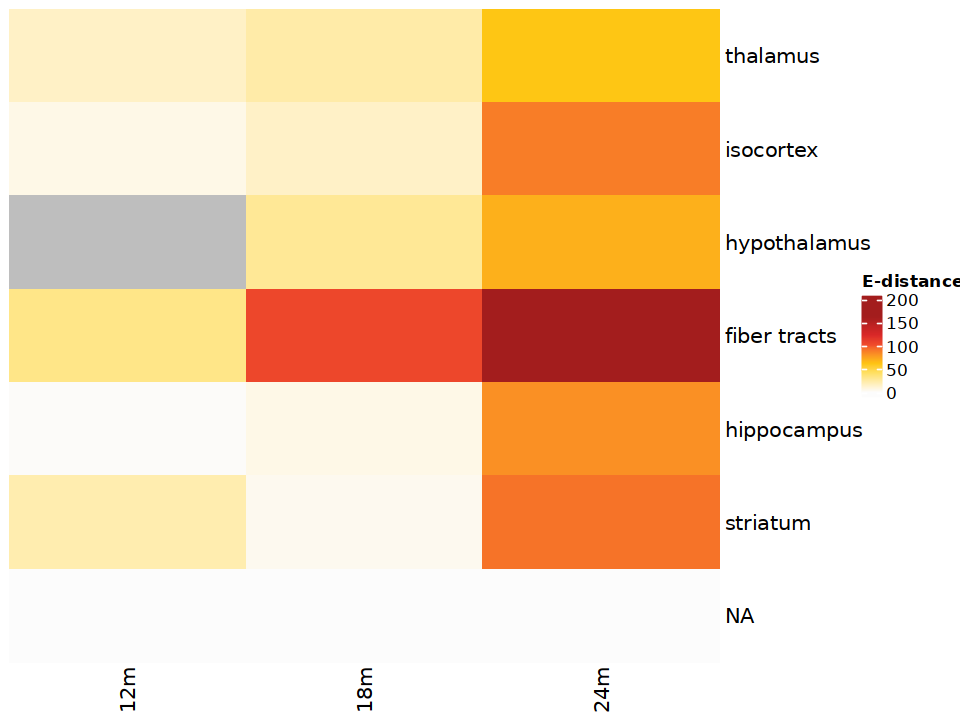

In [25]:
options(repr.plot.width = 8, repr.plot.height = 6)
p <- Heatmap(e_dist_mat, name = "E-distance", 
        col = jdb_palette("solar_rojos"),
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        show_row_names = TRUE,
        show_column_names = TRUE)
print(p)


Fig. 2g: Compute E-dist for variable genes *associated with* chromatin changes

In [26]:
e_dist_mat <- matrix(0, nrow = length(unique(merged_obj@meta.data$annotation_assigned)), ncol = length(age_groups))
colnames(e_dist_mat) <- age_groups
rownames(e_dist_mat) <- unique(merged_obj@meta.data$annotation_assigned)

In [28]:
for (region in region_annotations){
  DefaultAssay(object = merged_obj) <- "RNA_Spatial"
  merged_obj <- NormalizeData(merged_obj, assay = "RNA_Spatial")
  merged_obj <- FindVariableFeatures(merged_obj, assay = "RNA_Spatial", selection.method = "vst", nfeatures = 3000)
  overlap_genes <- intersect(gene_list[[region]], rownames(merged_obj))
  merged_obj <- ScaleData(merged_obj, assay = "RNA_Spatial",features = overlap_genes)
  merged_obj <- RunPCA(merged_obj, assay = "RNA_Spatial", features = overlap_genes, npcs = 30)
  subset_obj <- subset(merged_obj, subset = annotation_assigned  == gsub('_', ' ', region))

  for (age_compare in age_groups){
    if (sum(subset_obj@meta.data$age == age_compare) > 0){
      e_dist <- e_distance(age_compare, '3m', subset_obj)
      e_dist_mat[gsub('_', ' ', region), age_compare] <- e_dist
    } else {
      e_dist_mat[gsub('_', ' ', region), age_compare] <- NA
    }
  }
}

Centering and scaling data matrix

Warning message in PrepDR(object = object, features = features, verbose = verbose):
"The following 22 features requested have zero variance (running reduction without them): Sprr2a2, Sprr2a1, G530012D18Rik, Lhx4, Gata4, 4930467E23Rik, 4930555G01Rik, AW822073, Hoxb3, Hoxc9, Tlx1, 4930477E14Rik, Hoxd8, 4930447A16Rik, Ascl5, Zbed6, 9230104M06Rik, 4930404H24Rik, 1810049J17Rik, Hist1h3h, 4921522P10Rik, 4933440J02Rik"
PC_ 1 
Positive:  Rtn1, Ppp3r1, Syt1, Cyfip2, Cx3cl1, Ppp3ca, Atp6v1b2, Enc1, Prkar1b, Basp1 
	   Lingo1, Nsg2, Mapk1, Pja2, Sv2b, Snca, Syn2, Ppp3cb, Ttc3, Atp6v1d 
	   Nell2, Sncb, Kalrn, Atp6v1c1, Chst1, Wasf1, Dlgap1, Sult4a1, Mef2c, Camk2a 
Negative:  Apod, Mbp, Plekhb1, Cldn11, Csrp1, Ndrg1, Qk, Gsn, Litaf, Ugt8a 
	   Slc44a1, Phldb1, Fa2h, Cers2, Gna12, Slc12a2, Ptma, S100b, Tmbim1, Grb14 
	   Slain1, Hepacam, Mt1, Npc1, Sgk1, Prdx1, Arhgef10, Jam3, Glul, Bin1 
PC_ 2 
Positive:  Tcf7l2, Ntng1, Shox2, Rora, Ptpn4, Plcb4, Grm1, Kcnc2, Pdp

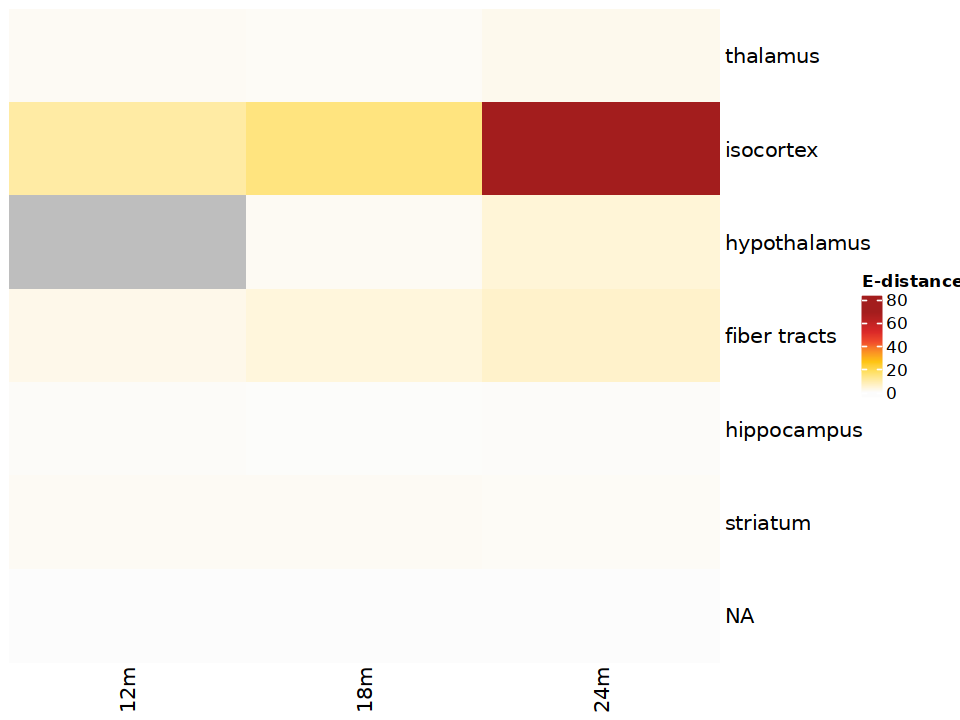

In [29]:
options(repr.plot.width = 8, repr.plot.height = 6)
p <- Heatmap(e_dist_mat, name = "E-distance", 
        col = jdb_palette("solar_rojos"),
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        show_row_names = TRUE,
        show_column_names = TRUE)
print(p)